# Layout Regression Testing (difftest)

As a photonics or electronics layout library grows, it becomes easy to
accidentally change a component's geometry — e.g. when refactoring an
enclosure, tweaking routing parameters, or updating a dependency.

kfactory ships a **GDS difftest** workflow (inspired by
[lytest](https://github.com/atait/lytest)) that catches these regressions:

| Function | What it does |
|---|---|
| `kf.utils.difftest(component, dirpath, dirpath_run)` | Full pytest-style regression test: first run saves a golden reference; later runs compare and raise on mismatch |
| `kf.utils.diff(ref_file, run_file)` | Compare two GDS files; returns `True` if they differ |
| `kf.utils.xor(old_layout, new_layout)` | In-memory XOR: returns a `DKCell` visualising old / new / XOR layers |

All three surface differences at the polygon level (per layer) using KLayout's
`LayoutDiff` engine.

## Setup

In [1]:
import pathlib
import tempfile

import kfactory as kf


class LAYER(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)
    SLAB: kf.kdb.LayerInfo = kf.kdb.LayerInfo(2, 0)


L = LAYER()
kf.kcl.infos = L

## Building two versions of a component

To demonstrate the tools we create the same straight waveguide component
in two slightly different configurations (v1 = 500 nm wide, v2 = 600 nm wide).

In [2]:
wg_v1 = kf.kcl.kcell("wg_v1")
wg_v1.shapes(kf.kcl.layer(L.WG)).insert(
    kf.kdb.Box(kf.kcl.to_dbu(10), kf.kcl.to_dbu(0.5))
)
wg_v1.add_port(
    port=kf.Port(
        name="o1",
        trans=kf.kdb.Trans(2, False, 0, 0),
        width=kf.kcl.to_dbu(0.5),
        layer=kf.kcl.layer(L.WG),
        kcl=kf.kcl,
    )
)
wg_v1.add_port(
    port=kf.Port(
        name="o2",
        trans=kf.kdb.Trans(0, False, kf.kcl.to_dbu(10), 0),
        width=kf.kcl.to_dbu(0.5),
        layer=kf.kcl.layer(L.WG),
        kcl=kf.kcl,
    )
)

wg_v2 = kf.kcl.kcell("wg_v2")
wg_v2.shapes(kf.kcl.layer(L.WG)).insert(
    kf.kdb.Box(kf.kcl.to_dbu(10), kf.kcl.to_dbu(0.6))  # 600 nm — wider
)
wg_v2.add_port(
    port=kf.Port(
        name="o1",
        trans=kf.kdb.Trans(2, False, 0, 0),
        width=kf.kcl.to_dbu(0.6),
        layer=kf.kcl.layer(L.WG),
        kcl=kf.kcl,
    )
)
wg_v2.add_port(
    port=kf.Port(
        name="o2",
        trans=kf.kdb.Trans(0, False, kf.kcl.to_dbu(10), 0),
        width=kf.kcl.to_dbu(0.6),
        layer=kf.kcl.layer(L.WG),
        kcl=kf.kcl,
    )
)

print(f"v1 bounding box: {wg_v1.dbbox()}")
print(f"v2 bounding box: {wg_v2.dbbox()}")

v1 bounding box: (-5,-0.25;5,0.25)
v2 bounding box: (-5,-0.3;5,0.3)


## `kf.utils.xor` — in-memory comparison

`xor` accepts two `KCLayout` objects and returns a `DKCell` with three
sub-cells stacked vertically:

- **old** — the reference layout
- **new** — the updated layout
- **xor** — per-layer XOR regions (non-empty only where the two differ)

This is useful during interactive development: call it in a notebook or
script to visualise what changed before committing.

Running XOR on differences...
straight_width: XOR difference on layer WG (1/0)
XOR result cell: straight_width_difftest
XOR bounding box: (-5,-10.8;5,10.75)


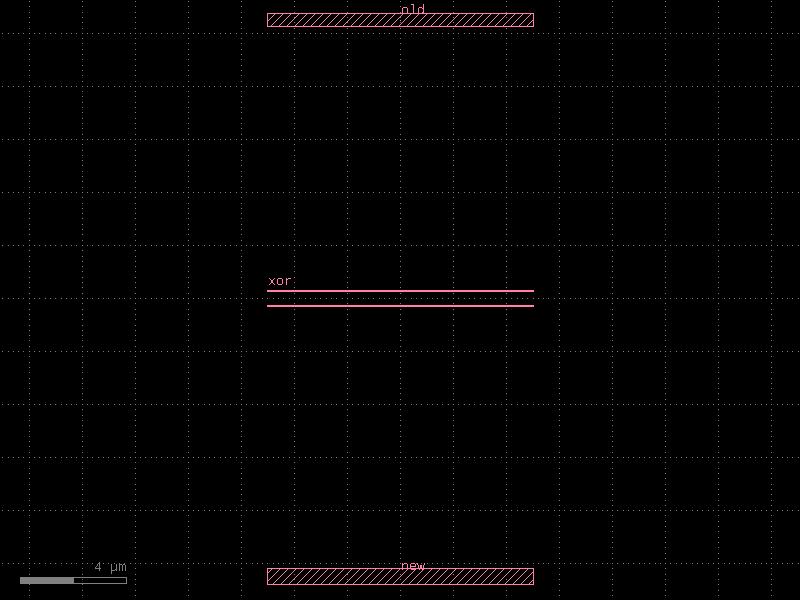

In [3]:
# Each comparison layout must be its own KCLayout
kcl_ref = kf.KCLayout("xor_ref", infos=LAYER)
kcl_run = kf.KCLayout("xor_run", infos=LAYER)

L_ref = LAYER()
L_run = LAYER()

ref_cell = kcl_ref.kcell("straight")
ref_cell.shapes(kcl_ref.layer(L_ref.WG)).insert(
    kf.kdb.Box(kcl_ref.to_dbu(10), kcl_ref.to_dbu(0.5))
)

run_cell = kcl_run.kcell("straight")
run_cell.shapes(kcl_run.layer(L_run.WG)).insert(
    kf.kdb.Box(kcl_run.to_dbu(10), kcl_run.to_dbu(0.6))  # wider
)

# xor() takes the layouts (not the cells)
xor_result = kf.utils.xor(
    old=ref_cell,
    new=run_cell,
    test_name="straight_width",
    stagger=True,  # spread old / new / xor vertically for easy inspection
)
print(f"XOR result cell: {xor_result.name}")
print(f"XOR bounding box: {xor_result.dbbox()}")
xor_result.plot()

The XOR layer highlights only the strips that differ between
v1 (500 nm) and v2 (600 nm) — exactly the 50 nm offset on each edge.

## `kf.utils.diff` — file-based comparison

`diff` loads two GDS files, runs `LayoutDiff`, and returns `True` when
they differ.  It also prints a per-layer summary of what changed.

In [4]:
with tempfile.TemporaryDirectory() as tmpdir:
    tmp = pathlib.Path(tmpdir)

    ref_file = tmp / "ref.gds"
    run_same_file = tmp / "run_same.gds"
    run_changed_file = tmp / "run_changed.gds"

    wg_v1.write(str(ref_file))

    # A copy that is geometrically identical
    wg_v1_copy = kf.kcl.kcell("wg_v1_copy")
    wg_v1_copy.shapes(kf.kcl.layer(L.WG)).insert(
        kf.kdb.Box(kf.kcl.to_dbu(10), kf.kcl.to_dbu(0.5))
    )
    wg_v1_copy.write(str(run_same_file))

    # The wider variant
    wg_v2.write(str(run_changed_file))

    # Identical files → False
    is_diff_same = kf.utils.diff(
        ref_file=ref_file,
        run_file=run_same_file,
        xor=False,
        test_name="wg_same",
        ignore_cell_name_differences=True,
    )
    print(f"Identical files differ? {is_diff_same}")

    # Changed file → True (XOR printed to stdout)
    is_diff_changed = kf.utils.diff(
        ref_file=ref_file,
        run_file=run_changed_file,
        xor=True,
        test_name="wg_changed",
        ignore_cell_name_differences=True,
    )
    print(f"Changed files differ? {is_diff_changed}")

cell name differs wg_v1
Identical files differ? False
cell name differs wg_v1
Running XOR on differences...
wg_changed: XOR difference on layer WG (1/0)
Changed files differ? True


## `kf.utils.difftest` — pytest integration

`difftest` is the high-level helper designed to be called from **pytest**
tests.  Its workflow:

1. Write the component to `dirpath_run/<name>.gds`
2. If no reference exists in `dirpath/<name>.gds` → copy as reference,
   raise `AssertionError` (first run always "fails" to prompt review)
3. If reference exists and files are byte-identical → pass silently
4. If files differ → run XOR, show diff in KLayout, ask whether to
   accept as new reference (interactive), raise `GeometryDifferenceError`

### Recommended project layout

```
my_pdk/
├── src/my_pdk/components.py
└── tests/
    ├── test_components.py
    ├── gds_ref/          ← committed golden references
    └── gds_run/          ← git-ignored run outputs (.gitignore: gds_run/)
```

### Example pytest test

```python
# tests/test_components.py
import pathlib
import pytest
import kfactory as kf
from my_pdk.components import straight_wg

GDS_REF = pathlib.Path(__file__).parent / "gds_ref"
GDS_RUN = pathlib.Path(__file__).parent / "gds_run"


@pytest.mark.parametrize("width,length", [(0.5, 10), (0.8, 20)])
def test_straight_wg(width: float, length: float) -> None:
    """Regression test: geometry must not change unexpectedly."""
    component = straight_wg(width=width, length=length)
    kf.utils.difftest(
        component=component,
        dirpath=GDS_REF,
        dirpath_run=GDS_RUN,
    )
```

**First run** — reference files don't exist yet:
```
pytest tests/ -v
FAILED test_straight_wg[0.5-10]
  AssertionError: Reference GDS file for 'straight_wg_...' not found.
                  Writing to .../gds_ref/straight_wg_....gds
```
Inspect the newly-written GDS, commit `gds_ref/`, then re-run — all green.

**After an accidental geometry change**:
```
pytest tests/ -s
FAILED ... straight_wg_...: XOR difference on layer 1/0
Save current GDS as the new reference (Y)? [Y/n]
```
Answer **Y** to accept an intentional change, **n** to reject.

## Ignore options

All three functions accept the same set of fine-tuning flags:

| Flag | Default | When to use |
|---|---|---|
| `ignore_sliver_differences` | `False` | Suppress 1-DBU rounding artefacts from polygon merging |
| `ignore_cell_name_differences` | `False` | Allow hierarchy renames without flagging geometry diffs |
| `ignore_label_differences` | `False` | Ignore text-label changes (e.g. port names stored as labels) |

Sliver suppression is especially useful after upgrading kfactory: polygon
merging improvements can shift edge coordinates by ±1 DBU (0.001 µm) without
any real geometry change.

## Demonstrating identical XOR (no differences)

In [5]:
kcl_a = kf.KCLayout("sliver_a", infos=LAYER)
kcl_b = kf.KCLayout("sliver_b", infos=LAYER)
L_a, L_b = LAYER(), LAYER()

cell_a = kcl_a.kcell("box")
cell_b = kcl_b.kcell("box")

cell_a.shapes(kcl_a.layer(L_a.WG)).insert(kf.kdb.Box(0, 0, 10000, 500))
cell_b.shapes(kcl_b.layer(L_b.WG)).insert(kf.kdb.Box(0, 0, 10000, 500))

xor_identical = kf.utils.xor(cell_a, cell_b, test_name="identical_boxes")
print(f"XOR of identical cells is empty: {xor_identical.dbbox().empty()}")

XOR of identical cells is empty: True


## Summary

| Use case | Recommended tool |
|---|---|
| Notebook / script: visualise what changed interactively | `kf.utils.xor(old_kcl, new_kcl)` |
| Script / CI: check whether two GDS files are equivalent | `kf.utils.diff(ref_file, run_file)` |
| pytest: full regression suite with golden references | `kf.utils.difftest(component, dirpath, dirpath_run)` |

**Workflow summary**:
1. Write `difftest` calls in your pytest suite
2. First run creates `gds_ref/*.gds` — review and commit them
3. Add `gds_run/` to `.gitignore`
4. CI runs `pytest` non-interactively — any geometry change fails the build
5. Intentional changes: re-run locally with `pytest -s` and answer **Y**
   to update the golden references, then commit the updated `gds_ref/*.gds`

## See Also

| Topic | Where |
|-------|-------|
| Session caching (GDS round-trip) | [Utilities: Session Cache](session_cache.py) |
| Creating a full PDK | [PDK: Creating a PDK](../pdk/creating_pdk.py) |
| Boolean / region operations | [Core Concepts: Geometry](../concepts/geometry.py) |
| Common pitfalls (difftest note) | [How-To: FAQ](../howto/faq.md) |